# **NLP continue**

**words need to be familiar with:**

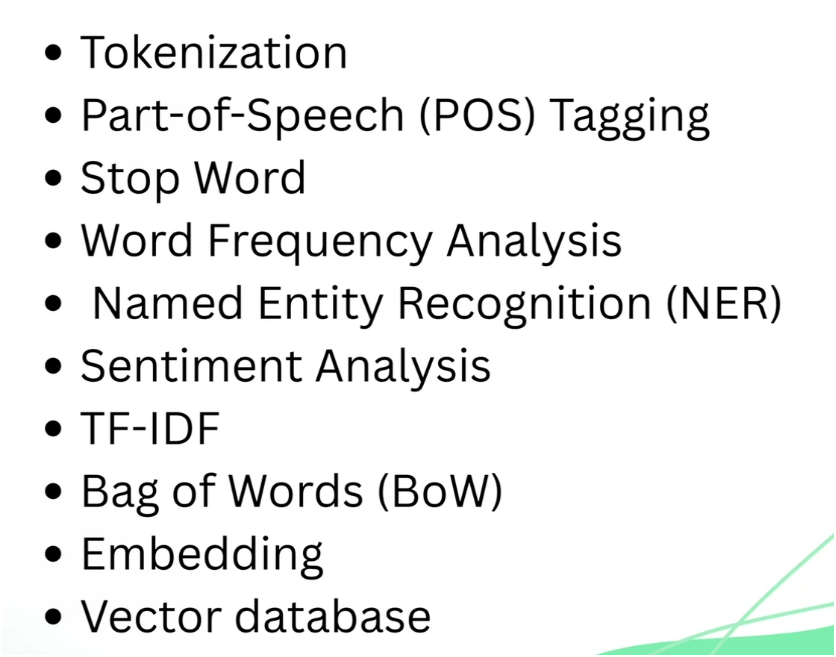

**tokenization = breaking sentence or words into token with their value**

**POS tagging = breaking words on the basis of noun, pronoun, adverb, adjective**

**Stop word = words which dont provide much meaning for model**

**Word Frequency Analysis = how many times a single word have been repeated**

**Name Entity Recognition(NER) = recognization of speicfic part of sentence like word, name, entity**

**Sentiment Analysis = whether a given sentence is positive or negative using polarity**

**TF-IDF (Term frequency| Inverse Document Frequency)= How many times a term is repreated in document**

**Bag of Words (BoW) = words without any redundancy**

**Embedding = converting text into vector**

**Vector database = storing vector datas into database**

In [1]:
!pip install nltk

In [4]:
import nltk
nltk.download("punkt")
nltk.download("punkt_tab")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


True

In [5]:
from nltk.tokenize import word_tokenize

text = "I love learning AI"
tokens = nltk.word_tokenize(text)
print(tokens)

['I', 'love', 'learning', 'AI']


**POS**

In [6]:
import nltk

nltk.download("punkt")
nltk.download("punk_tab")
nltk.download("averaged_perceptron_tagger_eng")

text = "John is running fast."

tokens = nltk.word_tokenize(text)

pos = nltk.pos_tag(tokens)

print(pos)

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Error loading punk_tab: Package 'punk_tab' not found in
[nltk_data]     index
[nltk_data] Downloading package averaged_perceptron_tagger_eng to
[nltk_data]     /root/nltk_data...
[nltk_data]   Unzipping taggers/averaged_perceptron_tagger_eng.zip.


[('John', 'NNP'), ('is', 'VBZ'), ('running', 'VBG'), ('fast', 'RB'), ('.', '.')]


**Stop word**

In [8]:
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

nltk.download("stopwords")

text = "I am learning DSML course."

stop_words = set(stopwords.words("english"))

tokens = word_tokenize(text)

filtered = [word for word in tokens if word.lower() not in stop_words]

print(filtered)

['learning', 'DSML', 'course', '.']


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


**Word Frequency Analysis**

In [10]:
from collections import Counter

text = "apple apple banana mango apple banana"

word = text.split()

word_freq = Counter(word)

print(word_freq)

Counter({'apple': 3, 'banana': 2, 'mango': 1})


**NER (Name Entity Recognititon)**

In [14]:
import spacy

nlp = spacy.load("en_core_web_sm")

text = "Elon Musk founded SpaceX in the Sankhamul."

doc = nlp(text)

for ent in doc.ents:
  print(ent.text, ent.label_)

Elon Musk PERSON
Sankhamul GPE


**Sentimental Analysis**

In [17]:
from textblob import TextBlob

text = "I love this laptop."

blob = TextBlob(text)

print(blob.sentiment)

# polarity > 0 = positive
# polarity < 0 = negative
# polarity = 0 => neutral

Sentiment(polarity=0.5, subjectivity=0.6)


**TF-IDF (Term Frequency - Inverse Document Frequency)**

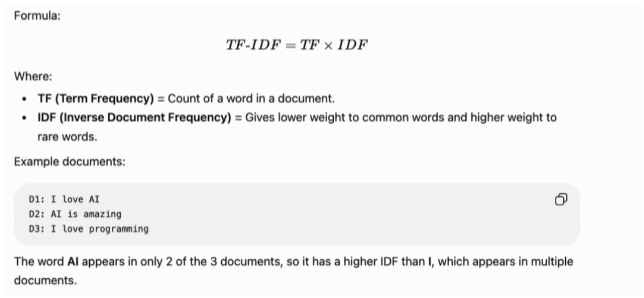

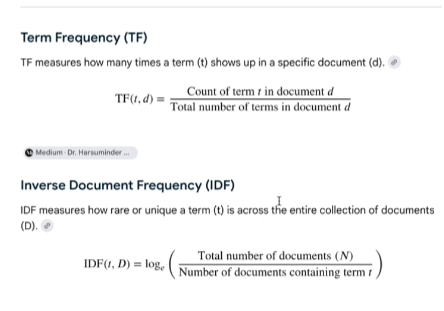

In [18]:
from sklearn.feature_extraction.text import TfidfVectorizer

# Sample documents
docs = [
    "I love learning AI",
    "AI is fun and powerful",
    "I love programming in Python"
]

# Initialize TF-IDF Vectorizer
vectorizer = TfidfVectorizer()

# Fit and transform the documents
tfidf_matrix = vectorizer.fit_transform(docs)

# Get feature names (words)
words = vectorizer.get_feature_names_out()

# Convert to array for readability
tfidf_array = tfidf_matrix.toarray()

# Display results
import pandas as pd
df = pd.DataFrame(tfidf_array, columns=words)
print(df)


         ai       and       fun        in        is  learning      love  \
0  0.517856  0.000000  0.000000  0.000000  0.000000  0.680919  0.517856   
1  0.355432  0.467351  0.467351  0.000000  0.467351  0.000000  0.000000   
2  0.000000  0.000000  0.000000  0.528635  0.000000  0.000000  0.402040   

   powerful  programming    python  
0  0.000000     0.000000  0.000000  
1  0.467351     0.000000  0.000000  
2  0.000000     0.528635  0.528635  


In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

documents = [
    "I love AI",
    "AI is amazing",
    "I love programming"
]

vectorizer = TfidfVectorizer()

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out)
print(X.toarray())

<bound method CountVectorizer.get_feature_names_out of TfidfVectorizer()>
[[0.70710678 0.         0.         0.70710678 0.        ]
 [0.4736296  0.62276601 0.62276601 0.         0.        ]
 [0.         0.         0.         0.60534851 0.79596054]]


**Bag of Word (BoW)**

represents text by counting the occurances of each word, ignoring grammer and word order

In [24]:
from sklearn.feature_extraction.text import CountVectorizer

documents = [
    "I love AI",
    "AI is amazing"
]

vectorizer = CountVectorizer()

X = vectorizer.fit_transform(documents)

print(vectorizer.get_feature_names_out())
print(X.toarray())

['ai' 'amazing' 'is' 'love']
[[1 0 0 1]
 [1 1 1 0]]


**Embedding or Vector Embedding or Vector to Word / Word to Vector (Vec2Word / Word2Vec)**

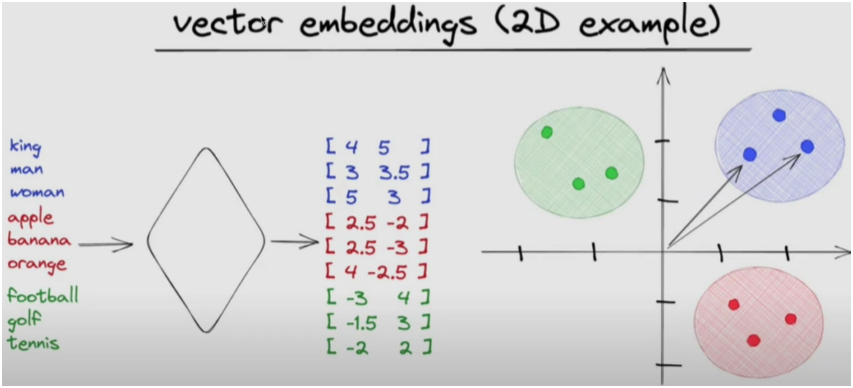

In [25]:
!pip install -U sentence-transformers

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 596.7/596.7 kB 8.9 MB/s eta 0:00:00
  Attempting uninstall: sentence-transformers
    Found existing installation: sentence-transformers 5.6.0
    Uninstalling sentence-transformers-5.6.0:
      Successfully uninstalled sentence-transformers-5.6.0


In [26]:
from sentence_transformers import SentenceTransformer

# 1. Load a pretrained Sentence Transformer model
model = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

# The sentences to encode
sentences = [
    "The weather is lovely today.",
    "It's so sunny outside!",
    "He drove to the stadium.",
]

# 2. Calculate embeddings by calling model.encode()
embeddings = model.encode(sentences)
print(embeddings.shape)
# [3, 384]

# 3. Calculate the embedding similarities
similarities = model.similarity(embeddings, embeddings)
print(similarities)
# tensor([[1.0000, 0.6660, 0.1046],
#         [0.6660, 1.0000, 0.1411],
#         [0.1046, 0.1411, 1.0000]])

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

(3, 384)
tensor([[1.0000, 0.6660, 0.1046],
        [0.6660, 1.0000, 0.1411],
        [0.1046, 0.1411, 1.0000]])


**Examples of vector db: supabase, chormadb, pinecone, pgadmin and many more..**